In [1]:
import numpy as np
import math
import json
from scipy.special import erfc
from scipy.stats import poisson
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm
from numba import njit

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# ============================================================
# GEOMETRIC PARAMETERS (cm)
# ============================================================
Lx = 0.2
Ly = 0.2
Lz = 0.2

dx = 0.0001
FCCD_cm = 0.1

In [3]:
# ============================================================
# DIFFUSION
# ============================================================
D = 28.9
dt = 1.0
t_max = 10000
Nt = int(t_max / dt)
sigma = math.sqrt(6 * D * dt) * 1e-4

In [4]:
# ============================================================
# LITHIUM
# ============================================================
r_Li = 0.002   # cm
cell_size = r_Li


In [5]:
# ============================================================
# ANNEALING
# ============================================================

'''
valori per detector ORTEC e non MIRION
t_ann = 18 * 60
T_ann = 623
'''

t_ann = 2 * 60 * 60
T_ann = 473

R = 1.98
H = 11800
D0 = 2.5e-3

Ns = 10 ** (21.27 - 2610 / T_ann)
print(f"{Ns:.3e}")
#D_Li = D0 * math.exp(-H / (R * T_ann))
D_Li = 7.66e-9 #cm-2 s

Nd_saturation = 1e14
alpha = 5.5e-10

5.650e+15


In [6]:
def ND_curve(depth, T_ann, t_ann):
    T_ann = T_ann + 273.15
    R = 1.98
    H = 11800
    D0 = 2.5e-3
    
    Ns = 10 ** (21.27 - 2610 / T_ann)
    D_Li = D0 * math.exp(-H / (R * T_ann))

    return Ns * erfc(depth / (2 * np.sqrt(D_Li * t_ann)))

In [7]:

# ============================================================
# SATURATION DEPTH
# ============================================================
depth_list = np.arange(0, 0.11 + dx, dx)
Nd_vals = Ns * erfc(depth_list / (2 * np.sqrt(D_Li * t_ann)))

idx = np.where(Nd_vals - Nd_saturation <= 0)[0][0]
saturation_depth = depth_list[idx]

print("Saturation depth =", saturation_depth * 10, "mm")

Saturation depth = 0.25 mm


0.0263
0.06570000000000001


Text(0, 0.5, 'Concentration (cm$^{-3}$)')

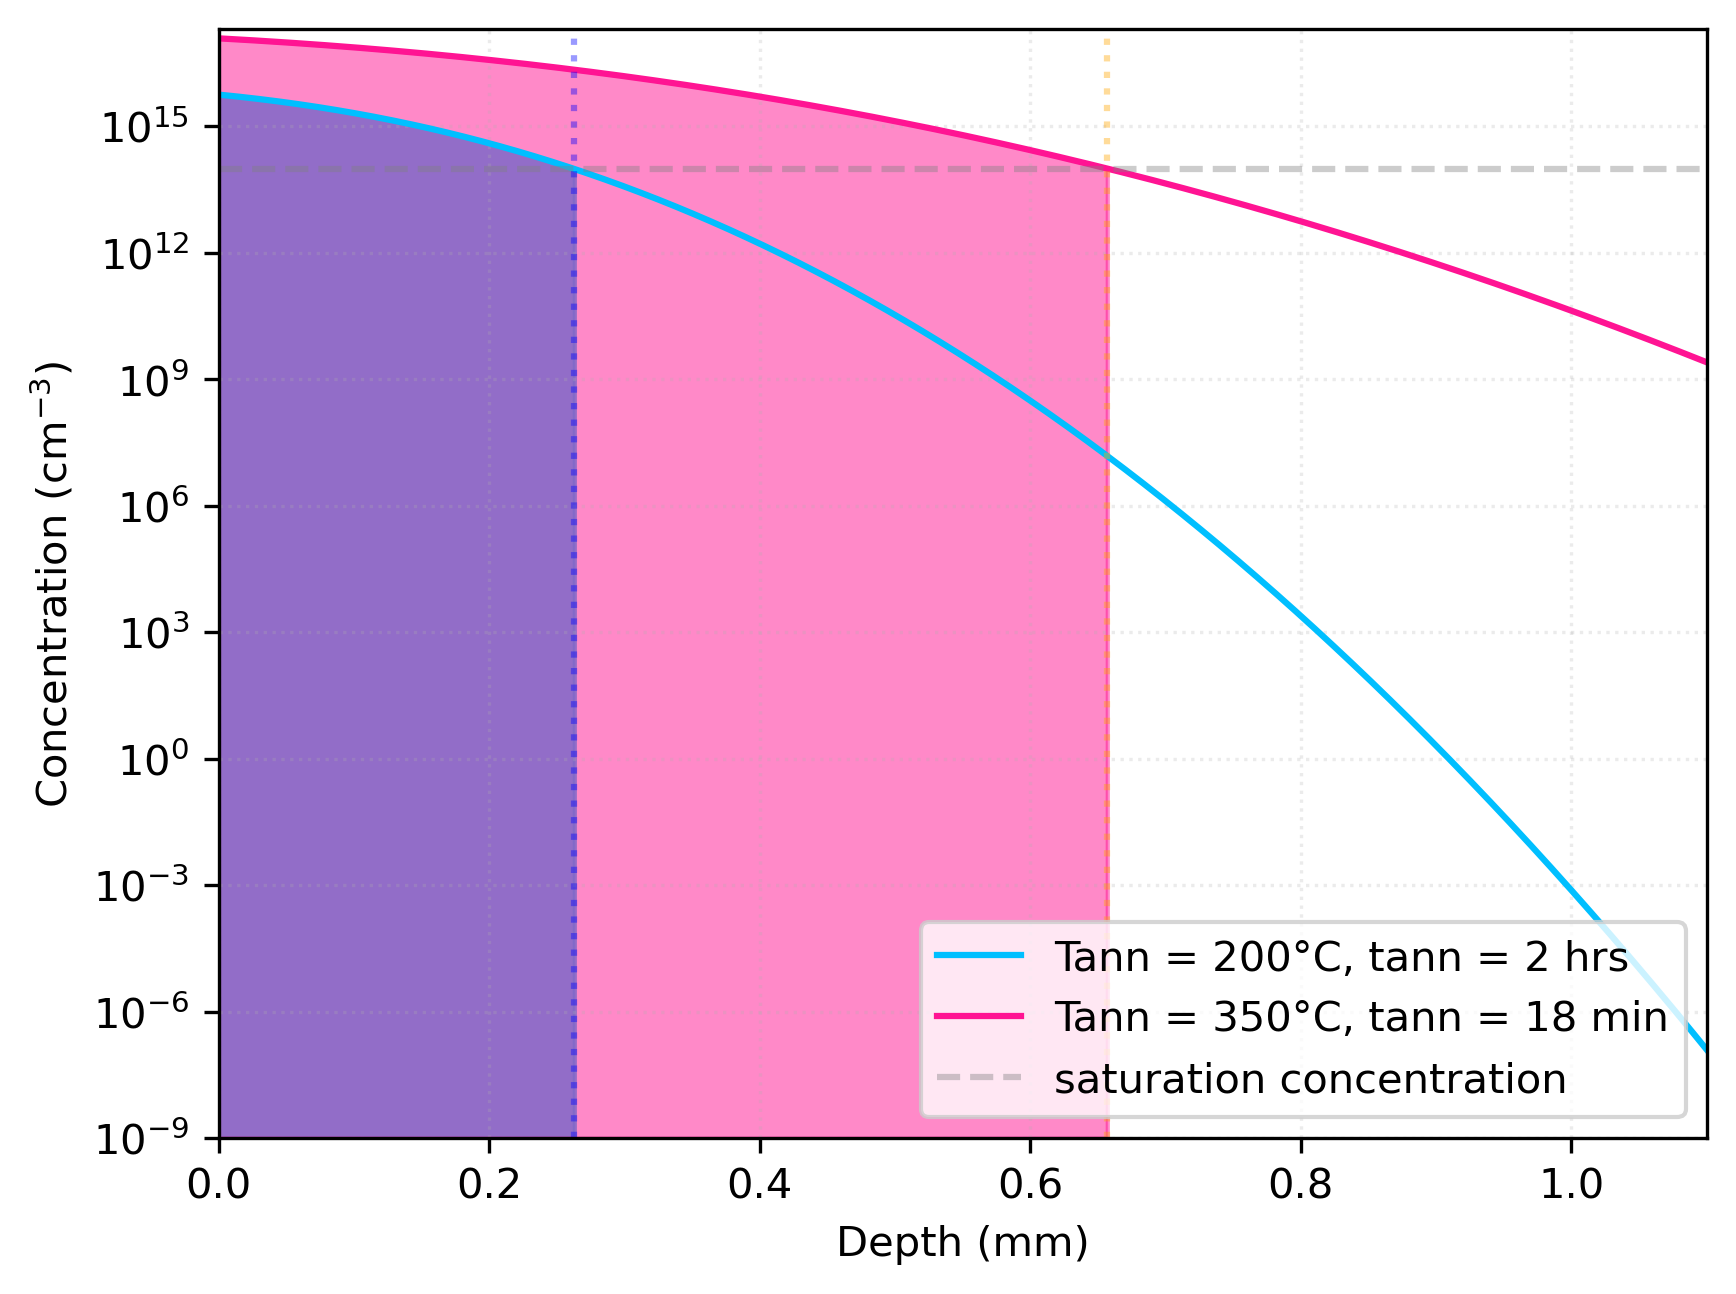

In [8]:

plt.figure(dpi = 300)
curve1 = ND_curve(depth_list, 200, 2*60*60)
curve2 = ND_curve(depth_list, 351, 18*60)

# valore minimo per il riempimento (0 non è possibile in scala log)
ymin_fill = 1e-9


idx1 = np.where(curve1 <= Nd_saturation)[0][0]
sat_depth1 = depth_list[idx1]

mask1 = depth_list <= sat_depth1

plt.plot(
    depth_list*10,
    curve1,
    color='deepskyblue',
    label='Tann = 200°C, tann = 2 hrs'
)

plt.fill_between(
    depth_list[mask1]*10,
    ymin_fill,
    curve1[mask1],
    color='deepskyblue',
    alpha=0.85
)


idx2 = np.where(curve2 <= Nd_saturation)[0][0]
sat_depth2 = depth_list[idx2]

mask2 = depth_list <= sat_depth2


print(sat_depth1)
print(sat_depth2)
plt.plot(
    depth_list*10,
    curve2,
    color='deeppink',
    label='Tann = 350°C, tann = 18 min'
)

plt.fill_between(
    depth_list[mask2]*10,
    ymin_fill,
    curve2[mask2],
    color='deeppink',
    alpha=0.5
)


# --- linea di saturazione ---
plt.hlines(
    Nd_saturation,
    0,
    max(depth_list*10),
    color='grey',
    alpha=0.4,
    ls='--',
    label='saturation concentration'
)


plt.axvline(
    sat_depth1*10,
    color='blue',
    alpha=0.4,
    ls=':'
)

plt.axvline(
    sat_depth2*10,
    color='orange',
    alpha=0.4,
    ls=':'
)

plt.legend(loc = 'lower right')
plt.grid(alpha=0.25, ls=':')

plt.yscale("log")

plt.xlim(0, max(depth_list*10))
plt.ylim(ymin_fill, 2e17)
plt.xlabel('Depth (mm)')
plt.ylabel(r'Concentration (cm$^{-3}$)')

In [9]:
# ============================================================
# LITHIUM PARTICLE
# ============================================================
class LiParticle:
    __slots__ = ("x", "y", "z", "r")

    def __init__(self, x, y, z, r):
        self.x = x
        self.y = y
        self.z = z
        self.r = r

In [10]:
# ============================================================
# TRUNCATED POISSON
# ============================================================
def truncated_poisson(lam, Nmax):
    if Nmax <= 0:
        return 0

    for _ in range(100):
        n = np.random.poisson(lam)
        if n <= Nmax:
            return n

    return Nmax

In [11]:
# ============================================================
# GRID INDEXING
# ============================================================
def get_index(x, y, z, nx, ny, nz):
    ix = min(max(int(x / cell_size), 0), nx - 1)
    iy = min(max(int(y / cell_size), 0), ny - 1)
    iz = min(max(int(z / cell_size), 0), nz - 1)
    return ix, iy, iz


In [12]:
# ============================================================
# OVERLAP CHECK
# ============================================================
def is_overlapping(x, y, z, r, cells, nx, ny, nz):
    ix, iy, iz = get_index(x, y, z, nx, ny, nz)

    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dz in (-1, 0, 1):
                jx, jy, jz = ix + dx, iy + dy, iz + dz

                if 0 <= jx < nx and 0 <= jy < ny and 0 <= jz < nz:
                    for p in cells[jx][jy][jz]:
                        if (x - p.x)**2 + (y - p.y)**2 + (z - p.z)**2 < (r + p.r)**2:
                            return True
    return False


In [13]:
# ============================================================
# LITHIUM GENERATION
# ============================================================
def generate_lithium():
    nx = int(Lx / cell_size)
    ny = int(Ly / cell_size)
    nz = int(Lz / cell_size)

    cells = [[[[] for _ in range(nz)] for _ in range(ny)] for _ in range(nx)]

    x_slices = np.arange(0, Lx + dx, dx)
    total = 0

    for xi in x_slices:
        if xi >= saturation_depth:
            continue

        Nd_val = Ns * erfc(xi / (2 * np.sqrt(D_Li * t_ann)))
        density = alpha * max(Nd_val - Nd_saturation, 0.0)

        lam = density * dx * Ly * Lz

        V_particle = (4/3) * math.pi * r_Li**3
        V_slice = dx * Ly * Lz
        N_max = int(V_slice / V_particle)

        N_i = truncated_poisson(lam, N_max)

        accepted = 0
        trials = N_i * 100

        for _ in range(trials):
            if accepted >= N_i:
                break

            x = xi + np.random.rand() * dx
            y = np.random.rand() * Ly
            z = np.random.rand() * Lz

            if not is_overlapping(x, y, z, r_Li, cells, nx, ny, nz):
                ix, iy, iz = get_index(x, y, z, nx, ny, nz)
                cells[ix][iy][iz].append(LiParticle(x, y, z, r_Li))
                accepted += 1
                total += 1

    print("Total Li particles =", total)
    return cells


In [14]:
# ============================================================
# GENERATE LITHIUM
# ============================================================
cells = generate_lithium()

Total Li particles = 972


In [15]:
# ============================================================
# CHARGE TRANSPORT + TRAPPING
# ============================================================
def charge_transport_3D(x_charges, N, cells,
                        x_saturation, dx,
                        Lx, Ly, Lz,
                        Nt, sigma, FCCD_cm, r):

    if np.isscalar(x_charges):
        x_charges = np.full(N, x_charges)

    nx = len(cells)
    ny = len(cells[0])
    nz = len(cells[0][0])

    collected = 0
    trapped = 0

    for n in range(N):
        x = x_charges[n]
        y = np.random.rand() * Ly
        z = np.random.rand() * Lz

        is_trapped = False

        for _ in range(Nt):
            x += sigma * np.random.randn()
            y += sigma * np.random.randn()
            z += sigma * np.random.randn()

            x = np.clip(x, 0, Lx)
            y = np.clip(y, 0, Ly)
            z = np.clip(z, 0, Lz)

            if x >= FCCD_cm:
                collected += 1
                break

            if x <= dx:
                is_trapped = True
                break

            if x <= x_saturation:
                ix, iy, iz = get_index(x, y, z, nx, ny, nz)

                for dx_ in (-1, 0, 1):
                    for dy_ in (-1, 0, 1):
                        for dz_ in (-1, 0, 1):
                            jx, jy, jz = ix + dx_, iy + dy_, iz + dz_

                            if 0 <= jx < nx and 0 <= jy < ny and 0 <= jz < nz:
                                for p in cells[jx][jy][jz]:
                                    if (x - p.x)**2 + (y - p.y)**2 + (z - p.z)**2 < r**2:
                                        is_trapped = True
                                        break

                            if is_trapped:
                                break
                        if is_trapped:
                            break

            if is_trapped:
                trapped += 1
                break

    return collected, trapped

In [16]:
# ============================================================
# CCE SIMULATION
# ============================================================
dx = 0.005
x_pos = np.arange(0, 0.11 + dx, dx)
N_charges = 250
N_repeat = 50

In [ ]:


CCE_matrix = np.zeros((len(x_pos), N_repeat))

for i, x0 in enumerate(tqdm(x_pos)):
    for j in range(N_repeat):
        collected, _ = charge_transport_3D(
            x0, N_charges, cells,
            saturation_depth, dx,
            Lx, Ly, Lz,
            Nt, sigma, FCCD_cm, r_Li
        )
        CCE_matrix[i, j] = collected / N_charges


 13%|█▎        | 3/23 [00:26<03:53, 11.70s/it]

In [ ]:
# ============================================================
# STATISTICS
# ============================================================
CCE_mean = CCE_matrix.mean(axis=1)
CCE_std = CCE_matrix.std(axis=1)


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# Main curve
ax.plot(
    x_pos * 10000,
    CCE_mean,
    lw=2.2,
    color="black",
    label="CCE"
)

# Uncertainty band (more transparent and cleaner)
ax.fill_between(
    x_pos * 10000,
    CCE_mean - CCE_std,
    CCE_mean + CCE_std,
    alpha=0.52,
    color="gray",
    linewidth=0
)

# Labels (slightly larger + clearer units)
ax.set_xlabel("Depth (um)", fontsize=11)
ax.set_ylabel("Charge Collection Efficiency (CCE)", fontsize=11)

# Grid (major only, subtle)
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.5)

# Improve axes limits (removes useless whitespace)
ax.set_xlim(x_pos.min() * 10000, x_pos.max() * 10000)
ax.set_ylim(-0.05, 1.05)

ax.axvline(0.263 * 1000, 0, 1, ls = '--', color = 'deepskyblue' )
# Tick styling
ax.tick_params(axis="both", which="major", labelsize=10, width=1)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:

# Bin della CCE
n_cce_bins = N_charges 
cce_bins = np.linspace(0, 1, n_cce_bins + 1)

# Matrice delle frequenze
density = np.zeros((n_cce_bins, len(x_pos)))

for i in range(len(x_pos)):
    density[:, i], _ = np.histogram(CCE_matrix[i, :], bins=cce_bins)

# Plot
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)


dx = x_pos[1] - x_pos[0]

x_edges = np.concatenate([
    [x_pos[0] - dx/2],
    x_pos[:-1] + dx/2,
    [x_pos[-1] + dx/2]
])

plt.pcolormesh(
    x_edges*10,
    cce_bins,
    density,
    cmap='viridis',
    norm=LogNorm(vmin=1, vmax=max(2, density.max())),
    shading='flat'
)

ax.plot(
    x_pos * 10,
    CCE_mean,
    lw=2.2,
    color="red",
    label="CCE"
)

plt.xlabel("Depth [cm]")
plt.ylabel("CCE")
plt.colorbar(label="Counts")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), dpi=150)

# tutte le realizzazioni Monte Carlo
for j in range(N_repeat):
    ax.plot(
        x_pos*10,
        CCE_matrix[:, j],
        color="black",
        alpha=0.15,
        lw=1
    )

# media
CCE_mean = np.mean(CCE_matrix, axis=1)

ax.plot(
    x_pos*10,
    CCE_mean,
    color="orange",
    lw=2.5,
    label="Mean CCE"
)

# deviazione standard
CCE_std = np.std(CCE_matrix, axis=1)

ax.fill_between(
    x_pos*10,
    CCE_mean-CCE_std,
    CCE_mean+CCE_std,
    alpha=0.25,
    label="±1σ"
)

ax.set_xlabel("Depth [cm]")
ax.set_ylabel("CCE")
ax.set_ylim(0,1.05)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE RESULTS
# ============================================================
filename = f"JSON/CCE_{r_Li*10000}um.json"

results = {
    "x_pos": x_pos.tolist(),
    "CCE_mean": CCE_mean.tolist(),
    "CCE_std": CCE_std.tolist()
}

if os.path.exists(filename):
    ans = input(f"{filename} exists. Overwrite? (y/n): ")
    if ans.lower() != "y":
        print("Cancelled")
        exit()

os.makedirs("JSON", exist_ok=True)
with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print("File saved:", filename)

# systematics

In [ ]:



def annealing_parameters(T_C, t_hours):

    """
    Input:
        T_C       temperatura in Celsius
        t_hours   tempo in ore

    Output:
        Ns
        D_Li
        saturation_depth
    """

    T = T_C + 273.15

    t_ann = t_hours * 3600


    # concentrazione superficiale
    Ns = 10**(21.27 - 2610/T)


    # diffusione Li
    D_Li = D0 * np.exp(-H/(R*T))


    # profilo profondità
    depth_list = np.arange(
        0,
        0.11 + dx,
        dx
    )


    Nd_vals = Ns * erfc(
        depth_list /
        (2*np.sqrt(D_Li*t_ann))
    )


    idx = np.where(
        Nd_vals <= Nd_saturation
    )[0]


    if len(idx)==0:
        saturation_depth = depth_list[-1]

    else:
        saturation_depth = depth_list[idx[0]]


    return Ns, D_Li, saturation_depth

In [ ]:
# temperatura (°C)

T_values = np.arange(
    200,
    400,
    100
)


# tempo annealing (ore)

time_values = np.arange(
    1,
    4,
    2
)


print(T_values)
print(time_values)

In [ ]:
dx = 0.01

In [ ]:

CCE_map = np.zeros(
    (
        len(T_values),
        len(time_values)
    )
)


Depth_map = np.zeros_like(CCE_map)



# profondità dove calcolare CCE

x_test = np.arange(
    0,
    0.11+dx,
    dx
)


N_charges = 10
N_repeat = 3


In [ ]:


for i,T in enumerate(T_values):

    for j,t in enumerate(time_values):


        print("\n==========================")
        print(
            f"T = {T} °C   time = {t} h"
        )


        # -----------------------------
        # annealing
        # -----------------------------

        Ns,D_Li,saturation_depth = annealing_parameters(
            T,
            t
        )


        print(
            "D_Li = ",
            D_Li
        )

        print(
            "Saturation depth = ",
            saturation_depth*10,
            " mm"
        )


        Depth_map[i,j]=saturation_depth



        # -----------------------------
        # genera nuovo Li profile
        # -----------------------------

        cells = generate_lithium()



        # -----------------------------
        # simulazione CCE
        # -----------------------------


        CCE_depth=[]


        for x0 in tqdm(x_test):

            collected_total=0


            for rep in range(N_repeat):


                collected,trapped = charge_transport_3D(
                    x0,
                    N_charges,
                    cells,
                    saturation_depth,
                    dx,
                    Lx,
                    Ly,
                    Lz,
                    Nt,
                    sigma,
                    FCCD_cm,
                    r_Li
                )


                collected_total += collected/N_charges



            CCE_depth.append(
                collected_total/N_repeat
            )


        # media su tutto il detector

        CCE_map[i,j]=np.mean(
            CCE_depth
        )



print("FINITO")

In [ ]:
plt.figure(figsize=(8,6))


plt.imshow(
    CCE_map,
    origin="lower",
    aspect="auto",
    extent=[
        time_values[0],
        time_values[-1],
        T_values[0],
        T_values[-1]
    ],
    cmap="viridis"
)


plt.colorbar(
    label="Average CCE"
)


plt.xlabel(
    "Annealing time [h]"
)

plt.ylabel(
    "Annealing temperature [°C]"
)


plt.title(
    "CCE sensitivity to annealing conditions"
)


plt.show()

In [ ]:
plt.figure(figsize=(8,6))


plt.imshow(
    Depth_map*10,
    origin="lower",
    aspect="auto",
    extent=[
        time_values[0],
        time_values[-1],
        T_values[0],
        T_values[-1]
    ],
    cmap="plasma"
)


plt.colorbar(
    label="Saturation depth [mm]"
)


plt.xlabel(
    "Annealing time [h]"
)

plt.ylabel(
    "Annealing temperature [°C]"
)


plt.title(
    "Li diffusion depth"
)


plt.show()

In [ ]:

# mesh degli assi

T_grid, time_grid = np.meshgrid(
    time_values,
    T_values
)


fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)


surf = ax.plot_surface(
    time_grid,
    T_grid,
    CCE_map,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)


# barra colore

fig.colorbar(
    surf,
    shrink=0.5,
    aspect=10,
    label="Average CCE"
)

ax.scatter(
    time_grid,
    T_grid,
    CCE_map,
    color="red",
    s=30
)

ax.set_xlabel(
    "Annealing time [h]"
)

ax.set_ylabel(
    "Annealing temperature [°C]"
)

ax.set_zlabel(
    "CCE"
)


ax.set_title(
    "CCE dependence on annealing conditions"
)


# vista iniziale

ax.view_init(
    elev=30,
    azim=220
)


plt.show()